## Supervised Learning
#### by **Hiram Cruz**
<p><img src="https://preview.redd.it/rfgtsej8fhv71.jpg?auto=webp&s=99a5d000ff2baaac79a8d15c7135c3677f105159" width="1000"></p>

## Exploratory Data Analysis
<p>Vamos a trabajar con el conjunto de datos de <code>Heart Attack</code>, el objetivo es predecir bajo que escenario es más probable que un paciente pueda tener un ataque al corazón  Un experto en medicina cardiovasuclar puede predecir esto sin hacer uso de <i>Machine Learning</i>, pero probablemente no instantáneamente, ¡y ciertamente no si estamos tratando con cientos o miles de muestras!.
    
A continuación una breve explicación de las variables del dataset:
    
- <b>age:</b> Age of the patient
- <b>sex:</b> Sex of the patient
- <b>cp:</b> Chest pain type ~ 0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic
- <b>trtbps:</b> Resting blood pressure (in mm Hg)
- <b>chol:</b> Cholestoral in mg/dl fetched via BMI sensor
- <b>fbs:</b> (fasting blood sugar > 120 mg/dl) ~ 1 = True, 0 = False
- <b>restecg:</b> Resting electrocardiographic results ~ 0 = Normal, 1 = ST-T wave normality, 2 = Left ventricular hypertrophy
- <b>thalachh:</b> Maximum heart rate achieved
- <b>oldpeak:</b> Previous peak
- <b>slp:</b> Slope
- <b>caa:</b> Number of major vessels
- <b>thall:</b> Thalium Stress Test result ~ (0,3)
- <b>exng:</b> Exercise induced angina ~ 1 = Yes, 0 = No
- <b>output:</b>  Target variable</p>

In [3]:
# Importamos las librerias escensiales y nuestro archivo Archivo Heart Attack.csv - ¿Cuales son los factores que pueden incrementar o disminuir la probabilidad de un ataque al corazón?
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("C:/Users/hiram/Downloads")
df = pd.read_csv("Heart Attack.csv")


In [4]:
# Hacemos un EDA (Exploratory Data Analysis)
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Análisis Exploratorio")
profile.to_notebook_iframe() 

C:\Users\hiram\AppData\Local\Temp\ipykernel_31296\2451506196.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 429.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## k-Nearest Neighbors
<p>Habiendo hecho un Análisis Exploratorio de los factores que pueden o no tener más posibilidad de un ataque al corazón, es hora de crear tu primer clasificador!!! usando el algoritmo de k-NN.
    
<b>Nota</b>: es importante garantizar que los datos esten en el formato requerido por la librería de <code>scikit-learn</code>. La información debe estar en una matriz en la que cada columna sea una variable y cada fila una observación diferente, en este caso, el registro de análisis clinico por paciente. Y la variable objetivo debe ser una sola columna con el mismo número de observaciones.</p>

In [7]:
from sklearn.neighbors import KNeighborsClassifier
x_data=df.drop(["output"],axis=1)
y=df.output.values
knn=KNeighborsClassifier(n_neighbors=6)
knn.fit(x_data, y)

KNeighborsClassifier(n_neighbors=6)

## Predicción
<p>Una vez que entrenamos al clasificador k-NN, ahora lo podemos usar para predecir un nuevo registro. Para este caso,  no hay datos sin clasificar disponibles ya que todos se usaron para entrenar al modelo. Para poder calcular una predicción, vamos a usar el método <code>.predict()</code> pero, para esto vamos a simular una observación completamente nueva</p>

In [9]:
# Creamos un arreglo simulando una observación
X_new = pd.DataFrame({
    'age': [58],          
    'sex': [1],           
    'cp': [2],            
    'trtbps': [140],      
    'chol': [220],       
    'fbs': [0],           
    'restecg': [1],       
    'thalachh': [160],    
    'exng': [0],         
    'oldpeak': [1.2],     
    'slp': [1],          
    'caa': [0],            
    'thall': [2]})
# Predice la clasificación para el arreglo creado
y_new_pred = knn.predict(X_new)
print("Prediction: {}".format(y_new_pred))

Prediction: [1]


## Reconocimiento de digitos
<p>Hasta ahora, solo hemos realizado una clasificación binaria, ya que la variable objetivo tenía dos resultados posibles. En los siguientes ejercicios, trabajarás con el conjunto de datos de reconocimiento de dígitos MNIST, que tiene 10 clases, ¡los dígitos del 0 al 9! Una versión reducida del conjunto de datos <a href="http://yann.lecun.com/exdb/mnist/">MNIST</a> es uno de los conjuntos de datos incluidos en <code>scikit-learn</code>

Cada muestra de este conjunto de datos es una imagen de 28x28 que representa un dígito escrito a mano. Cada píxel está representado por un número entero en el rango de 1 a 784, lo que indica niveles variables de negro.

<p><img src="https://miro.medium.com/max/1400/1*hVdoiW35FXUE-fZ0HI30Tw.jpeg" width="350"></p>

In [11]:
# Importa el archivo de MNIST
digits = pd.read_csv("MNIST.csv")

In [12]:
# Crea una variable 'cols' para hacer referencia a todas las columnas que contienen la palabra 'pixel'
cols = [col for col in digits.columns if 'pixel' in col]

In [13]:
# Vamos a imprimir un digito
i = 2324
print("El número es:", digits.loc[i, 'label'])
plt.imshow(digits.loc[i,cols].values.reshape((28,28)).astype(float), cmap=plt.cm.gray_r, interpolation='nearest')

El número es: 3


## Train/Test
<p>Una de las principales diferencias entre la Estadística Clasica y el <i>Machine Learning</i> es la división del conjunto de datos en conjuntos de entrenamiento y prueba, con el objetivo de medir y cuantificar la precisión y el nivel de error en los datos que de alguna manera el modelo <i>"No ha visto"</i>. A continuación crearemos nuestros conjuntos de entrenamiento y prueba con el método <code>train_test_split</code> y mediremos cual es el nivel de precisión de nuestro modelo. El objetivo es <b>predecir cual es el digito dada una imagen</b>!!!. Para lo cual entrenaremos un clasificador <i>k-NN</i> a los datos de entrenamiento y luego calcularemos su precisión usando el método <code>accuracy_score()</code> en los datos de prueba ¿Como crees que en un modelo de Clasificación se calcule su precisión?. Parece bastante dificil, pero no lo es ;)</p>

In [21]:
# Importamos las librerías necesarias 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [23]:
# Crea los arreglos para las variables independientes y la variable objetivo
x = digits.drop('label', axis=1)
y = digits['label']  
#Creamos nuestros conjutos de entramiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=1)
# Instancia un clasificador k-NN con 14 vecinos(Al analizar los vecinos mas optimos concluimos que era mas optimo 1 vecino cercano)
knn = KNeighborsClassifier(n_neighbors=1)
# Ajusta (Entrenamiento) el clasificador en el conjunto de entrenamiento
knn.fit(x_train, y_train)
# Calcular las predicciones sobre el conjunto de prueba
y_pred = knn.predict(x_test)
# Verificar la precisión del modelo 
print("Precisión del modelo:", accuracy_score(y_test, y_pred))

Precisión del modelo: 0.9669047619047619


## Reconocimiento de tu imagen
<p>Con todo lo anterior, podemos hacer el reconocimiento de cualquier digito que dibujes, ¿Estás list@?</p>
<p>Dibuja en paint un numero de color blanco en fonde negro </p>
<P>Nuestro codigo le da las caracteristicas necesarias a nuestra imagen de paint para que pueda ser analizada por nuestro modelo y esta puede hacer su prediccion en base a los datos de MNIST</P>

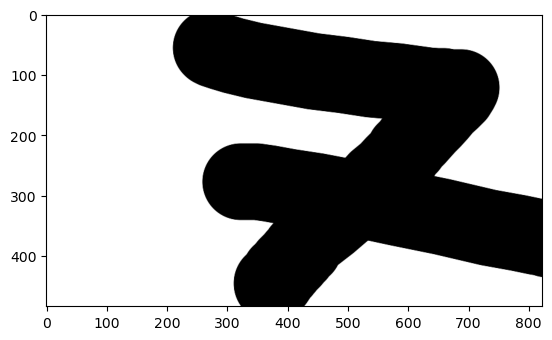

In [60]:
# Vamos a visualizar la imagen de un número que vas a crear en tu computador con la aplicación de paint, ésta imagen debe de tener un fondo negro y ser pintada en blanco, encontrarás un ejemplo en el repositorio
%matplotlib inline
image = plt.imread("Numero-6-test.png") # Coloca aquí la ruta de la imagen que hayas creado en formato jpg o png
plt.imshow(image)
plt.show()

In [62]:
# Con esta libreria transformaremos la imagen creada a un formato de 28x28 pixeles
from PIL import Image
pil = Image.open("Numero-6-test.png")
image_resize = pil.resize((28, 28))
# Vamos transformar la nueva imagen en un array donde se almacenara la información de los pixeles
pixels = np.asarray(image_resize)

In [64]:
# Necesitamos hacer algunas configuraciones a la imagen debido al formato de datos que esta alimentando al modelo y a la configuración de sklearn
arr = pixels.transpose(2, 0, 1).reshape(-1, pixels.shape[1])[0:28]
image_final = arr.ravel().reshape(1, -1)
image_final = pd.DataFrame(image_final, columns=x_train.columns)

El número es: 7


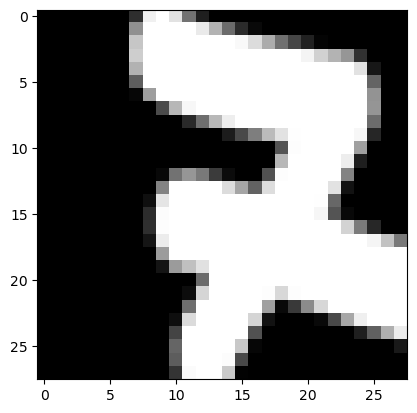

In [66]:
# Calculamos la predicción del modelo con el número que creado
print("El número es:", knn.predict(image_final)[0])
plt.imshow(arr, cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

<p> Nuestro modelo predice correctamente nuestra imagen 

## Overfit and Underfit
<p>¿Cual es mi numero ideal para elegir el parametro <i>k</i>? Vamos a calcular los valores de precisión para los conjuntos e entrenamiento y prueba para una rango de valores k. Al observar cómo difieren estos valores podremos observar cual es el mejor parametro sin caer en un <i>Overfit</i> o un <i>Underfit</i>.</p>

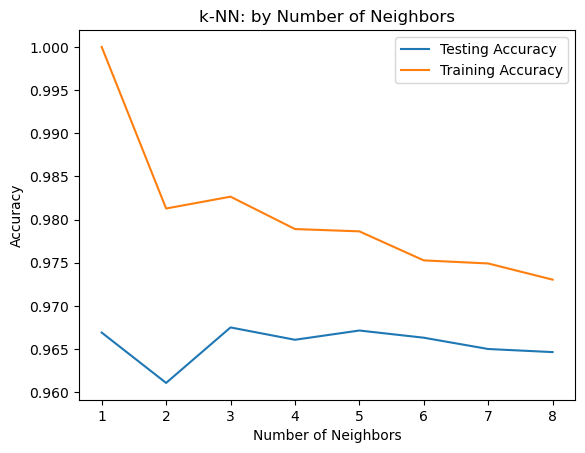

In [70]:
# Coniguración de arreglos iniciales
neighbors = np.arange(1, 9)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

# Loop para diferentes valores de k
for i, k in enumerate(neighbors):
    # Clasificador k-NN para el parametro k
    knn = KNeighborsClassifier(n_neighbors=k)

    # Ajuste del clasificador al dataset de entrenamiento
    knn.fit(x_train, y_train)
    
    # Calculo de precision sobre el dataset de entrenamiento
    train_accuracy[i] = knn.score(x_train, y_train)

    # Calculo de precision sobre el dataset de prueba
    test_accuracy[i] = knn.score(x_test, y_test)

# Grafico para encontrar un valor optimo de k
plt.plot(neighbors, test_accuracy, label = 'Testing Accuracy')
plt.plot(neighbors, train_accuracy, label = 'Training Accuracy')
plt.title('k-NN: by Number of Neighbors')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Se observa que a menor cantidad de vecino podemos obtener mejores resultados

## Regresión Logística
<p>Hacemos la predicción de la imagen, pero esta vez por medio de una Regresión Logística, contestaremos a la pregunta: ¿Cuál de los dos modelos te da mejores resultados?</p>

In [74]:
#Importamos las linrerias necesarias
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
#Standarizamos nuestros datos
scaler = StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)
#Creamos nuestro modelo de regresion logistica
model=LogisticRegression(solver="saga",max_iter=4000,tol=1e-3,random_state=1,verbose=1, C=1)
# Ajustamos (Entrenamiento) el clasificador en el conjunto de entrenamiento
clf=model.fit(x_train,y_train)
# Calcular las predicciones sobre el conjunto de prueba
y_pred=model.predict(x_test)
#Verificamos la prediccion del modelo
print(classification_report(y_test,y_pred))

convergence after 533 epochs took 829 seconds
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       853
           1       0.95      0.97      0.96       940
           2       0.92      0.92      0.92       835
           3       0.91      0.90      0.90       873
           4       0.93      0.94      0.93       829
           5       0.89      0.89      0.89       731
           6       0.95      0.96      0.96       800
           7       0.92      0.94      0.93       850
           8       0.91      0.86      0.88       846
           9       0.89      0.89      0.89       843

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



#### El modelo "Saga" destaco sobre los otros aunque con una diferencia minima pues todos tenian una prediccion del 91% sin embargo saga al ser mas efectiva para grandes catidades de datos mejoro en un 1% es resultado siendo suficiente para que la eligiera sobre otros modelos

El número es: 7


C:\Users\hiram\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


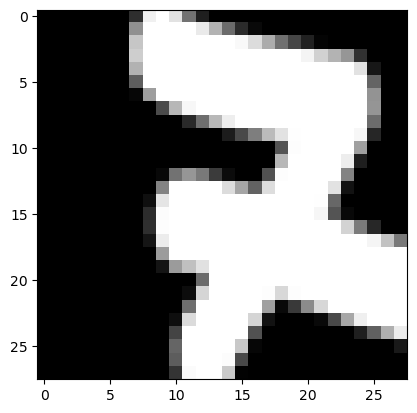

In [76]:
#Hacemos la prediccion
print("El número es:", model.predict(image_final)[0])
plt.imshow(arr, cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

<p>Al analizar mis resultados puedo ver que el modelo KNN con 1 vecino cercano es quien nos dio mejor rendimiento acercandose mas al 1, destacando  de los demas, prediciendo de manera muy buena las imagenes dadas,